# Pagoda2.1 Single-Dataset Workflow

This notebook runs the pagoda2.1 single-dataset scRNA-seq workflow on a
PBMC sample from GEO
([GSM5746259](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM5746259)).
The 10x triplet (matrix + barcodes + features) is in a local folder
named `data`. For **multimodal** data see the
[CITE-seq](pagoda2.1-citeseq.ipynb) and [ATAC /
multiome](pagoda2.1-multiome.ipynb) notebooks.

Pipeline steps are generic — the algorithm is a `method=` of
`runReduction()` / `runGraph()` / `runClustering()` / `runEmbedding()`
(there is no `runPCA`/`runLeiden`). `p2$run()` chains the standard
sequence below.

## Load counts

In [ ]:
p2 <- pagoda2::Pagoda2$from10x("data", verbose = FALSE)
dim(p2$getRawCounts())   # cells x genes

[1]  7532 36601

## QC

`runQC()` records per-cell molecule and gene counts and a
gene-vs-molecule QC flag in `p2$cellMeta`; failing cells are red.

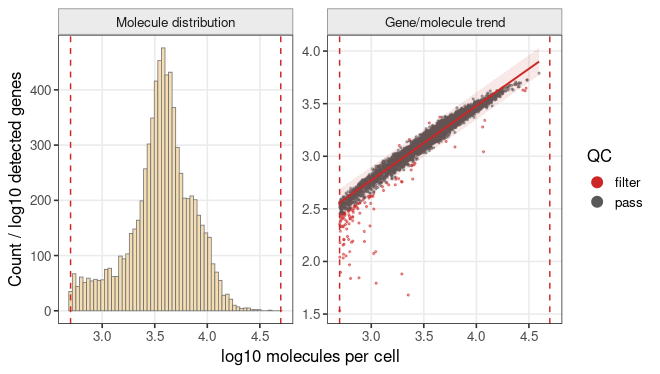

In [ ]:
p2$runQC(verbose = FALSE)
p2$plotQC()

Mitochondrial / ribosomal fractions, when the gene names support prefix
matching:

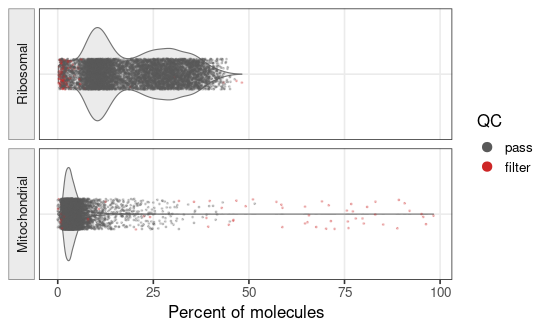

In [ ]:
p2$plotQCViolin()

## Run the standard workflow

Filtering, variance modeling, PCA, graph, UMAP, Leiden clustering, and
markers — stored under canonical names.

In [ ]:
p2$run(plots = "none", verbose = FALSE)

## Variance model

`runVariance()` fits the mean-variance trend and selects overdispersed
genes (red) for PCA.

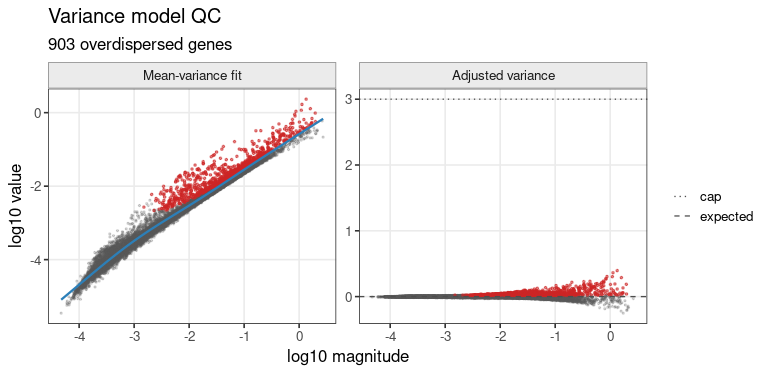

In [ ]:
p2$plotVarianceQC()

## PCA and UMAP

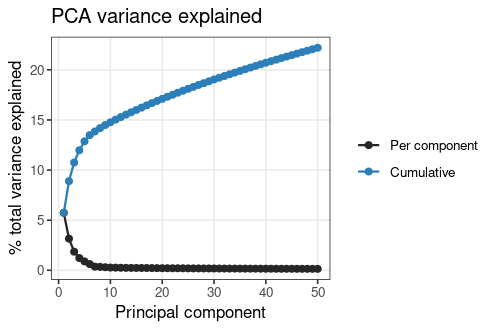

In [ ]:
p2$plotPCAElbow()

UMAP colored by the Leiden clustering:

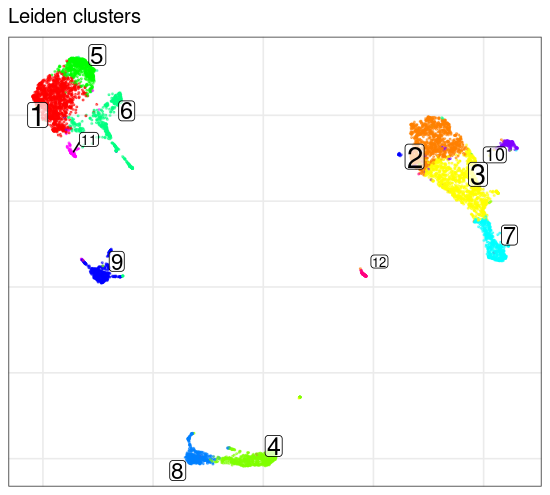

In [ ]:
p2$plotEmbedding(mark.groups = TRUE, size = 0.3, alpha = 0.5, title = "Leiden clusters")

## Markers

The default run computed markers for the Leiden grouping. The dot plot
shows the top markers per cluster (color = mean expression, size =
fraction of cells):

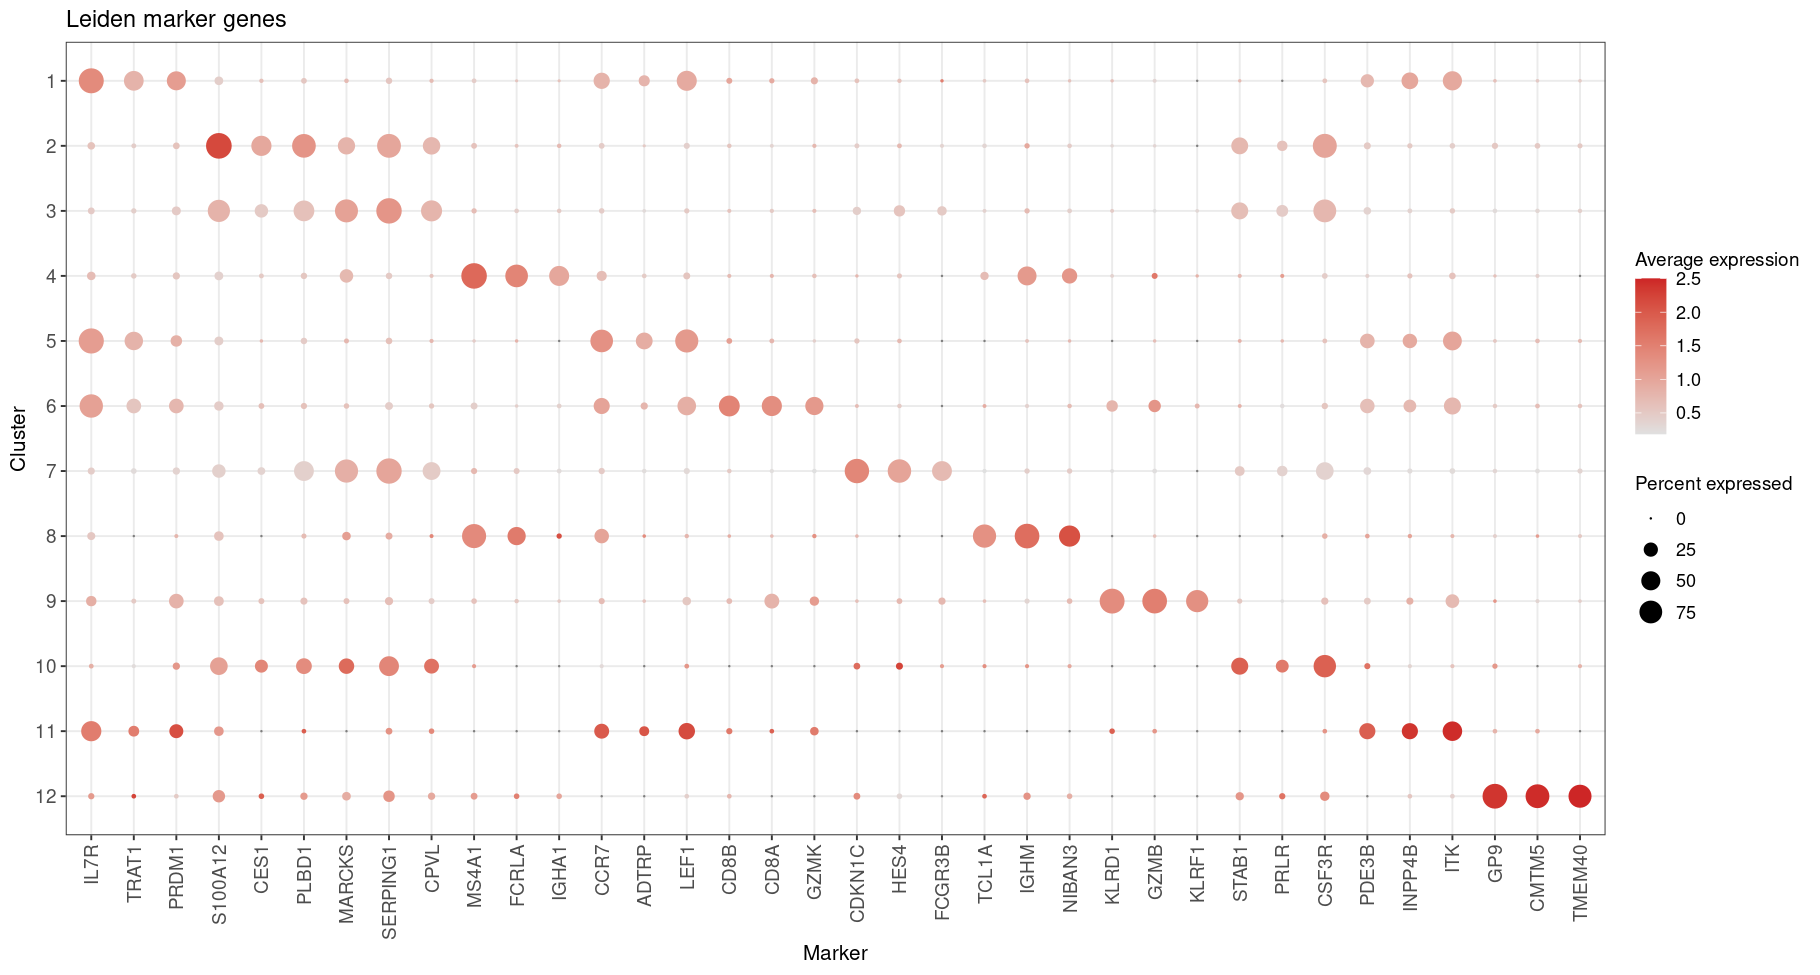

In [ ]:
p2$plotMarkerDotPlot(markers = "leiden", n.genes.per.group = 3, selection = "balanced",
                     order.groups = TRUE, dot.scale = 6) +
  ggplot2::labs(title = "Leiden marker genes") +
  ggplot2::theme(axis.text.x = ggplot2::element_text(angle = 90, hjust = 1, vjust = 0.5))

A native marker heatmap (no ComplexHeatmap dependency), with QC tracks
on top:

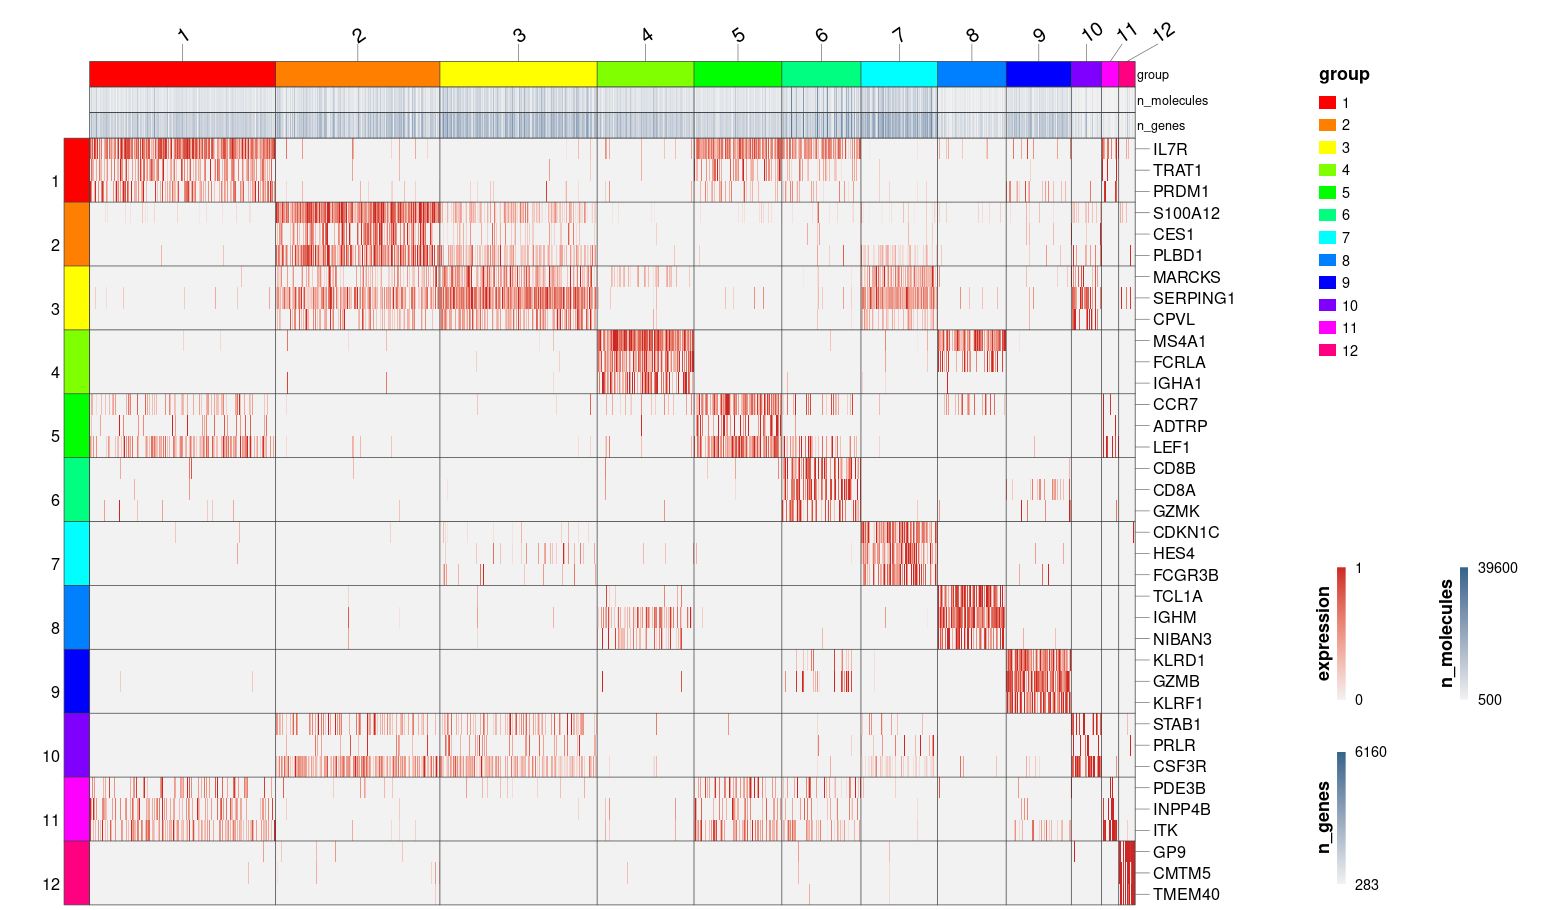

In [ ]:
p2$plotMarkerHeatmap(markers = "leiden", engine = "native", n.genes.per.group = 3,
                     selection = "balanced", column.metadata = c("n_molecules", "n_genes"),
                     row.label.font.size = 9, split = TRUE, show_heatmap_legend = TRUE)

## Next steps

Annotate clusters from the marker evidence and make the annotation the
default grouping:

``` r
p2$annotateClusters(from = "leiden", to = "cell_type",
                    map = c("1" = "T cells", "2" = "monocytes"), setDefault = TRUE)
```

The same plotting and marker methods then use `cell_type` by default.
For multiple modalities, each is a **facet** and the same steps take
`facet=` (per modality) or `facets=` (joint) — see the
[CITE-seq](pagoda2.1-citeseq.ipynb) and [ATAC /
multiome](pagoda2.1-multiome.ipynb) notebooks.